In [76]:
import numpy as np
from matplotlib import pyplot as plt


# Generating Random Points

generate "NUMBER_OF_POINTS" points in the chosen limit and save it in "DESTINATION_FILE"

In [77]:
DESTINATION_FILE = "10points.csv"
NUMBER_OF_POINTS = 10
X_RANGE = (0,100)
Y_RANGE = (0,100)

SEED = 42
rng = np.random.default_rng(SEED)

generated_points = rng.uniform(
    low=[X_RANGE[0], Y_RANGE[0]],
    high=[X_RANGE[1], Y_RANGE[1]],
    size=(NUMBER_OF_POINTS, 2)
)
generated_points = np.round(generated_points, 2)

np.savetxt(
    DESTINATION_FILE,
    generated_points,
    delimiter=",",
    header="x,y",
    comments="",
    fmt="%.2f"
)

# Load Data
reads the "DATA_FILE" which contains a header x, y and each row has two columns. saves the number of points into "n".

In [78]:
DATA_FILE = "10points.csv"

data = np.loadtxt("10points.csv", delimiter=",", skiprows=1)
n = data.shape[0]

In [79]:
data

array([[77.4 , 43.89],
       [85.86, 69.74],
       [ 9.42, 97.56],
       [76.11, 78.61],
       [12.81, 45.04],
       [37.08, 92.68],
       [64.39, 82.28],
       [44.34, 22.72],
       [55.46,  6.38],
       [82.76, 63.17]])

# Distance Matrix   
dist_matrix<sub>ij</sub> holds Euclidean distance between point<sub>i</sub> and point<sub>i</sub> 

In [80]:
diff = data[:, None, :] - data[None, :, :] # The distance between all pairs
dist_matrix = np.linalg.norm(diff, axis=2) # Root of sum of square of elements in the distance vector

# Initial Population
chooses "POPULATION_SIZE" random permutations 

In [81]:
POPULATION_SIZE = 100

SEED = 42
rng = np.random.default_rng(SEED)

indices = list(range(n))

# Random permutation of indices
population = np.array([
    rng.permutation(indices) for _ in range(POPULATION_SIZE)
])

# Fitness Function
uses inverse of Total distance to make minimization into maximization problem

In [82]:
def fitness_of(c):
    Total_distance = 0
    
    for i in range(1,n):
        prev_point = c[i-1]
        next_point = c[i]

        # Distance between two consecutive points in the chromosome
        Total_distance += dist_matrix[prev_point][next_point] 

    # return to the start point
    Total_distance += dist_matrix[c[-1]][c[0]]
    return 1 / Total_distance
    

# Crossover
Uses Ordered Crossover. Puts a random chunk of the first parent in the child and fills the left part with other parent by keeping the order 

In [83]:
def crossover(parent_a, parent_b, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    n = len(parent_a)

    # Empty array for child
    child = np.array([-1] * n)
    
    # Keeps used indices
    used = set() 

    # Place a random part of the first parent in child
    shared_range = rng.choice(n, size=2, replace=False)
    # Put the smaller one first
    shared_range.sort()

    for i in range(shared_range[0],shared_range[1]):
        child[i] = parent_a[i]
        used.add(parent_a[i])
    
    # Fill remaining part with the second parent keeping its order
    p_ptr = 0 # Parent pointer 
    for i in range(0,n):
        # If was not filled with parent_a 
        if child[i] == -1:

            # moves forward to find the first not used point in parent_b 
            while parent_b[p_ptr] in used:
                p_ptr += 1
            
            # Places the first unused point
            child[i] = parent_b[p_ptr]
            p_ptr += 1
            # point will not be seen again so it won't be necessary to add it into used set 

    return child

# Mutation
Using Inversion Mutation, selects a random range within the chromosome and reverses the order of its elements.

In [84]:
def Mutate(c, rng=None):
    if rng is None:
        rng = np.random.default_rng()
        
    n = len(c)

    # Choose random chunk 
    rev_range = rng.choice(n, size=2, replace=False)
    # Put the smaller one first
    rev_range.sort()
    start, end = rev_range[0], rev_range[1]
    
    # Reverse the order of elements
    c[start : end + 1] = c[start : end + 1][::-1]
    

# The Main Evolutionary Loop
For each generation, until reaching the limit given by user:
   1. Evaluate Fitness: Calculate 1/distance for all chromosomes.
   2. Track Champion: Log the all-time best route and fitness score.
   3. Selection: Run two tournaments to pick Parent A and Parent B.
   4. Crossover: Combine parents via Ordered Crossover to make children.
   5. Mutation: Flip random path segments via Inversion Mutation (1-5% chance).
   6. Replace: Overwrite the old population with the new generation.   

In [85]:
def Evolve(population, reps, tournament_size, mutation_chance = 0.05, rng= None):
    if rng is None:
        rng = np.random.default_rng()

    pop_size = population.shape[0] # Populatio size   
    fittests = [] # The fittest chromosome from each generation 
    
    gen_i = 0 # counter
    while gen_i < reps:

        # Fitness of every chromosome in the population 
        fitness = np.array([fitness_of(c) for c in population])

        # Find the fittest of current generation 
        fittest_idx = np.argmax(fitness)
        fittests.append(population[fittest_idx])
            
        # Create the next generation same size as current one
        next_generation = []
        while len(next_generation) < pop_size: 
            
            # -- First parent --

            # chooses random chromosomes
            competitioners = rng.choice(population, size=tournament_size, replace=False)
            f = np.array([fitness_of(c) for c in competitioners]) # Calculate their fitness

            # Choose the winner as parent
            parent_a = competitioners[np.argmax(f)]

            # -- Second parent --
            
            parent_b = parent_a
            tries = 0 
            # loop to prevent choosing a single chromosome as both parents 
            while np.array_equal(parent_a, parent_b) and tries < 5:
                # chooses random chromosomes
                competitioners = rng.choice(population, size=tournament_size, replace=False)
                f = np.array([fitness_of(c) for c in competitioners]) # Calculate their fitness

                # Choose the winner as parent
                parent_b = competitioners[np.argmax(f)]
                
                tries += 1

            # -- Crossover --

            child_a = crossover(parent_a, parent_b, rng)
            child_b = crossover(parent_b, parent_a, rng)

            # -- Mutation --

            if (rng.random() <= mutation_chance):
                Mutate(child_a, rng)
            next_generation.append(child_a)

            if (rng.random() <= mutation_chance):
                Mutate(child_b, rng)
            next_generation.append(child_a)

        gen_i += 1
        population = np.array(next_generation)

    return fittests

In [ ]:
SEED = 42
rng = np.random.default_rng(42)

population = init_pop

results = Evolve(population,
                 reps= 50,
                 tournament_size= 3,
                 rng= rng
                 )

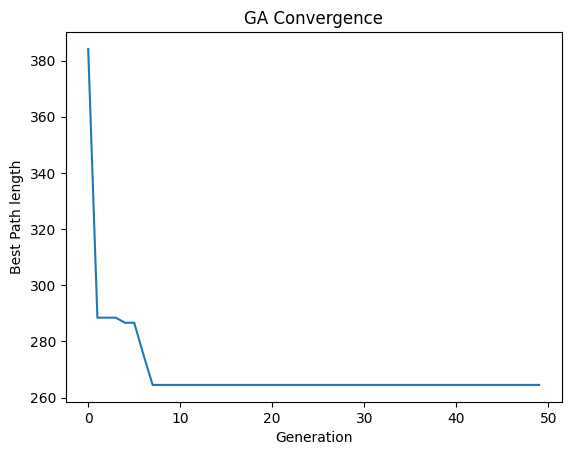

In [87]:
path_len = [1/fitness_of(c) for c in results]

plt.plot(path_len)
plt.xlabel("Generation")
plt.ylabel("Best Path length")
plt.title("GA Convergence")
plt.show()

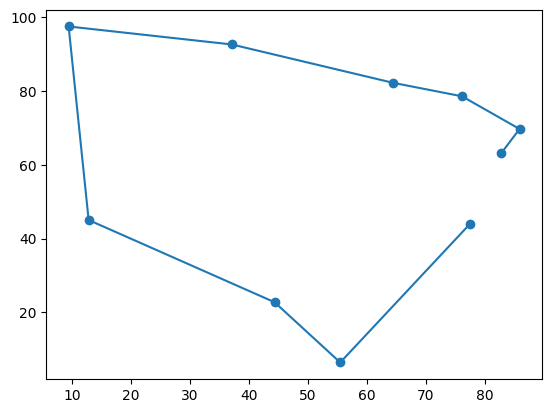

In [91]:
ans_points = np.array([ data[idx] for idx in results[-1]])

plt.plot(ans_points[:, 0], ans_points[:, 1])
plt.scatter(data[:, 0], data[:, 1])
plt.show()

In [92]:
ans_points[:, 0]

array([77.4 , 55.46, 44.34, 12.81,  9.42, 37.08, 64.39, 76.11, 85.86,
       82.76])